# Kalbų atpažinimo modelių palyginimas: N-Grams vs. Transformer

Čia lyginami du geriausiai pasirodę metodai
1. **N-Grams + LinearSVC**
2. **Fine-tuned Transformer** : `Mike0307/multilingual-e5-language-detection`)

**Tiriamoji grupė:** Germanų kalbos (`deu`, `nld`, `swe`, `fry`)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import pipeline as hf_pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification

sns.set(style="whitegrid")

C:\Users\LAURYNAS\PycharmProjects\NLP_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Duomenų paruošimas


In [2]:

target_languages = ['deu', 'nld', 'swe', 'fry']


df = pd.read_csv("hf://datasets/agentlans/tatoeba-english-translations/All.csv.gz")


df_filtered = df[df["Language"].isin(target_languages)]

# Randame mažiausią klasę balansavimui
min_count = df_filtered["Language"].value_counts().min()
print(f"Mažiausia klasė turi {min_count} įrašų. Balansuojame duomenis...")


df_balanced = pd.concat(
    [
        group.sample(min_count, random_state=42) 
        for _, group in df_filtered.groupby("Language")
    ],
    ignore_index=True
)


df_balanced = df_balanced.drop_duplicates(subset=['Translation'])

print("\nGalutinis duomenų pasiskirstymas:")
print(df_balanced['Language'].value_counts())

# Padaliname į Train/Test (80% / 20%)
X = df_balanced['Translation']
y = df_balanced['Language']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nMokymo imtis: {len(X_train)}, Testavimo imtis: {len(X_test)}")

Mažiausia klasė turi 369 įrašų. Balansuojame duomenis...

Galutinis duomenų pasiskirstymas:
Language
deu    369
nld    369
swe    369
fry    324
Name: count, dtype: int64

Mokymo imtis: 1144, Testavimo imtis: 287


## 2. Metodas A: N-Grams + LinearSVC
Tai tradicinis NLP metodas, kuris naudoja simbolių n-gramas (nuo 2 iki 5 simbolių ilgio) ir tiesinį atraminių vektorių klasifikatorių.

In [3]:
print("Treniruojamas LinearSVC modelis...")
start_time = time.time()


ngram_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(2, 5))),
    ('clf', LinearSVC())
])

# Apmokome modelį
ngram_pipeline.fit(X_train, y_train)

# Prognozuojame
y_pred_svc = ngram_pipeline.predict(X_test)

svc_time = time.time() - start_time
svc_acc = accuracy_score(y_test, y_pred_svc)

print(f"LinearSVC baigta. Laikas: {svc_time:.2f}s, Tikslumas: {svc_acc:.4f}")

Treniruojamas LinearSVC modelis...
LinearSVC baigta. Laikas: 0.18s, Tikslumas: 0.9721


## 3. Metodas B: Transformeris (Mike0307/multilingual-e5)
Naudojame iš anksto apmokytą ir specifiniam uždaviniui pritaikytą transformerį.

In [4]:
print("Kraunamas Transformer modelis...")
model_name = "Mike0307/multilingual-e5-language-detection"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

trans_pipe = hf_pipeline("text-classification", model=model, tokenizer=tokenizer)

transformer_map = {
    17: "deu",
    10: "nld",
    15: "fry",
    39: "swe"
}

print("Vykdoma prognozė su Transformeriu (gali užtrukti be GPU)...")
start_time = time.time()

y_pred_trans = []


for text in X_test:

    out = trans_pipe(text, top_k=1, truncation=True, max_length=512)[0]
    

    label_num = int(out["label"].replace("LABEL_", ""))
    

    pred_lang = transformer_map.get(label_num, "UNKNOWN")
    y_pred_trans.append(pred_lang)

trans_time = time.time() - start_time
trans_acc = accuracy_score(y_test, y_pred_trans)

print(f"Transformeris baigta. Laikas: {trans_time:.2f}s, Tikslumas: {trans_acc:.4f}")

Kraunamas Transformer modelis...


Device set to use cpu


Vykdoma prognozė su Transformeriu (gali užtrukti be GPU)...
Transformeris baigta. Laikas: 11.42s, Tikslumas: 0.9373


## 4. Rezultatų palyginimas ir vizualizacija

C:\Users\LAURYNAS\AppData\Local\Temp\ipykernel_8392\3175361653.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Modelis', y='Tikslumas', data=results_df, palette='viridis')


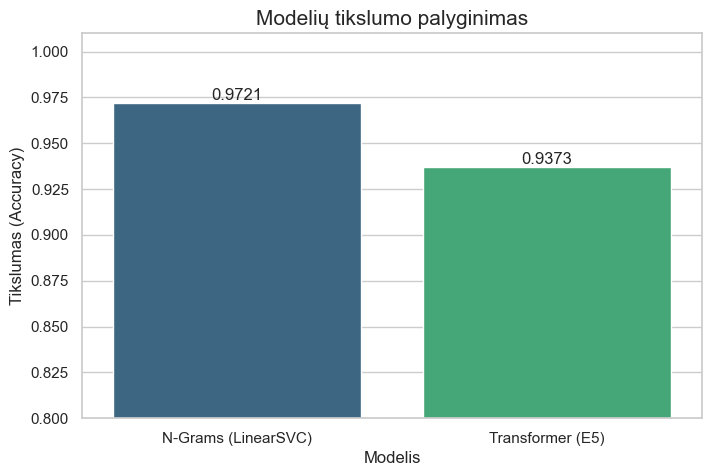

In [5]:
# 1. Tikslumo palyginimas (Bar Chart)
results_df = pd.DataFrame({
    'Modelis': ['N-Grams (LinearSVC)', 'Transformer (E5)'],
    'Tikslumas': [svc_acc, trans_acc]
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Modelis', y='Tikslumas', data=results_df, palette='viridis')
plt.ylim(0.8, 1.01)
plt.title('Modelių tikslumo palyginimas', fontsize=15)
plt.ylabel('Tikslumas (Accuracy)')

# Pridedame reikšmes ant stulpelių
for i in ax.containers:
    ax.bar_label(i, fmt='%.4f')

plt.show()

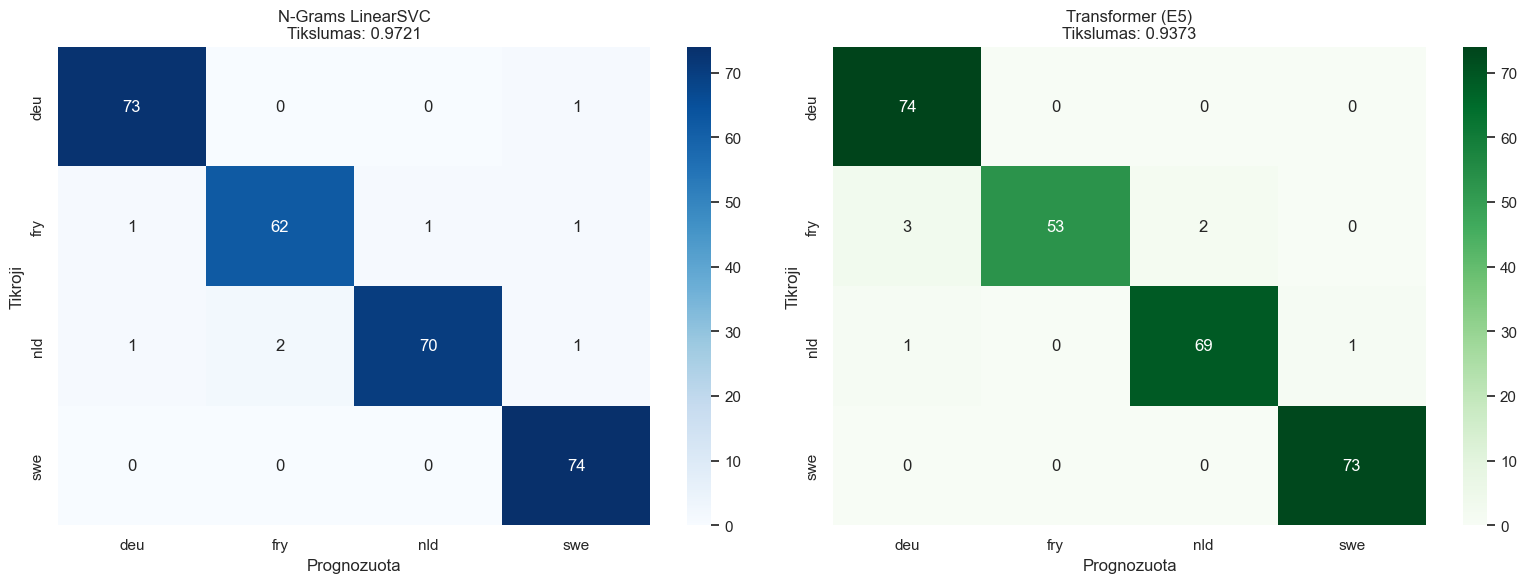

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels = sorted(list(set(y_test))) # Unikalios kalbos

# LinearSVC matrica
cm_svc = confusion_matrix(y_test, y_pred_svc, labels=labels)
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title(f'N-Grams LinearSVC\nTikslumas: {svc_acc:.4f}')
axes[0].set_xlabel('Prognozuota')
axes[0].set_ylabel('Tikroji')

# Transformer matrica
cm_trans = confusion_matrix(y_test, y_pred_trans, labels=labels)
sns.heatmap(cm_trans, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title(f'Transformer (E5)\nTikslumas: {trans_acc:.4f}')
axes[1].set_xlabel('Prognozuota')
axes[1].set_ylabel('Tikroji')

plt.tight_layout()
plt.show()

In [8]:

print("\n=== N-Grams (LinearSVC) Ataskaita ===")
print(classification_report(y_test, y_pred_svc, target_names=labels))

print("\n=== Transformer (E5) Ataskaita ===")

print(classification_report(y_test, y_pred_trans, labels=labels, target_names=labels, zero_division=0))


=== N-Grams (LinearSVC) Ataskaita ===
              precision    recall  f1-score   support

         deu       0.97      0.99      0.98        74
         fry       0.97      0.95      0.96        65
         nld       0.99      0.95      0.97        74
         swe       0.96      1.00      0.98        74

    accuracy                           0.97       287
   macro avg       0.97      0.97      0.97       287
weighted avg       0.97      0.97      0.97       287


=== Transformer (E5) Ataskaita ===
              precision    recall  f1-score   support

         deu       0.95      1.00      0.97        74
         fry       1.00      0.82      0.90        65
         nld       0.97      0.93      0.95        74
         swe       0.99      0.99      0.99        74

   micro avg       0.97      0.94      0.96       287
   macro avg       0.98      0.93      0.95       287
weighted avg       0.98      0.94      0.95       287



In [9]:
print(f"N-Grams mokymo+prognozavimo laikas: {svc_time:.4f} s")
print(f"Transformer prognozavimo laikas: {trans_time:.4f} s")
print(f"Santykis: Transformeris buvo {trans_time/svc_time:.1f} kartų lėtesnis (be GPU).")

N-Grams mokymo+prognozavimo laikas: 0.1810 s
Transformer prognozavimo laikas: 11.4159 s
Santykis: Transformeris buvo 63.1 kartų lėtesnis (be GPU).
